In [3]:
import torch
import numpy as np
from tqdm.notebook import tqdm
from torchvision import datasets

import matplotlib.pyplot as plt

In [4]:
def load_mnist_simple(
    train: bool = True,
    root: str = "./data",
) -> tuple[np.ndarray, np.ndarray]:
    num_class = 10
    dataset = datasets.MNIST(
        root=root,
        train=train,
        download=True
    )

    images = np.stack([img for img, _ in dataset])
    images = images.astype(np.uint8)

    labels = np.array([label for _, label in dataset])
    one_hot = np.eye(num_class)[labels]

    return images, one_hot

def label_to_onehot(label: int, num_class: int = 10) -> np.ndarray:
    one_hot = np.zeros(num_class)
    one_hot[label] = 1
    return one_hot


def onehot_to_label(one_hot: np.ndarray) -> np.ndarray:
    return np.argmax(one_hot)


In [5]:
class CrossEntropyLoss:

    def forward(self, pred: np.ndarray, target: np.ndarray) -> float:
        self.batch_size = pred.shape[0]
        self.target = target

        logits_max = pred.max(axis=1, keepdims=True)
        exp_pred = np.exp(pred - logits_max)

        self.softmax = exp_pred / exp_pred.sum(axis=1, keepdims=True)

        log_sum_exp = np.log(exp_pred.sum(axis=1, keepdims=True))
        loss = (-np.sum(target * pred, axis=1, keepdims=True) + logits_max + log_sum_exp)

        return loss.mean()

    def backward(self) -> np.ndarray:
        return (self.softmax - self.target) / self.batch_size

    def __call__(self, pred: np.ndarray, target: np.ndarray) -> float:
        return self.forward(pred, target)

In [6]:
def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(0, x)

def drelu(act: np.ndarray, grad: np.ndarray) -> np.ndarray:
    return grad * np.where(act > 0, 1, 0)

def softmax(x : np.ndarray) -> np.ndarray:
    max_x = np.max(x, axis=1, keepdims=True)
    exp_x = np.exp(x - max_x)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [17]:
def normalize(sample: np.ndarray) -> np.ndarray:
    s_min = np.min(sample, axis=-1, keepdims=True)
    s_max = np.max(sample, axis=-1, keepdims=True)
    return (sample - s_min) / (s_max - s_min) *2 - 1

def initialization_params(size: tuple[int, int], mode: str="normal", seed: int=None, empas: str="in") -> np.ndarray:
    rng = np.random.default_rng(seed)
    n_in, n_out = size
    gain = np.sqrt(2)

    if mode == 'normal':
        return rng.standard_normal(size=size)

    elif mode == "xavier_normal":
        std = gain * np.sqrt(2.0 / (n_in + n_out))
        return rng.normal(0, std, size=size)

    elif mode == "xavier_uniform":
        bound = gain * np.sqrt(6.0 / (n_in + n_out))
        return rng.uniform(-bound, bound, size=size)

    elif mode == "kaiming_normal":
        std = gain * np.sqrt(1.0 / (n_in if empas=="in" else n_out))
        return rng.normal(0, std, size=size)

    elif mode == "kaiming_uniform":
        bound = gain * np.sqrt(3.0 / (n_in if empas=="in" else n_out))
        return rng.uniform(-bound, bound)
    else:
        raise ValueError("Данный тип инициализации весов еще не был введен")

def create_layers(n_input: int, n_output: int, mode: str="normal", seed: int=None, n_hidden: int=128) -> tuple[np.ndarray, ...]:
    W1 = initialization_params(size=(n_input, n_hidden), mode=mode, seed=seed)
    b1 = initialization_params(size=(1, n_hidden), mode=mode, seed=seed)

    W2 = initialization_params(size=(n_hidden, n_output), mode=mode, seed=seed)
    b2 = initialization_params(size=(1, n_output), mode=mode, seed=seed)
    return (W1, b1, W2, b2)
    

In [ ]:
def train(
        data: tuple[np.ndarray, np.ndarray],
        n_input: int,
        n_output: int,
        mode: str="normal",
        batch_size: int=16,
        epochs: int=1,
        lr: float=0.01,
        shuffle: bool = False,
        norm = False,
        seed = None,
):
    W1, b1, W2, b2 = create_layers(n_input, n_output, mode=mode, seed=seed)
    imgs, targets = data
    criterion = CrossEntropyLoss()

    data_size = imgs.shape[0]
    num_batches = data_size // batch_size
    total = num_batches * batch_size

    print(f"Всего: {num_batches} батчей размером: {batch_size}")

    loop = tqdm(range(epochs), leave=False)
    for epoch in loop:
        if shuffle:
            rng = np.random.default_rng(seed)
            idx = rng.permutation(data_size)
            imgs = imgs[idx]
            targets = targets[idx]

        imgs_batches = imgs[:total].reshape(num_batches, batch_size, n_input)
        targets_batches = targets[:total].reshape(num_batches, batch_size, n_output)

        if norm:
                imgs_batches = normalize(imgs_batches)

        train_loader = (imgs_batches, targets_batches)

        for i, (imgs_batch, target) in enumerate(zip(*train_loader)):
               out1 = imgs_batch @ W1 + b1
               act1 = relu(out1)

               pred = act1 @ W2 + b2
               loss = criterion(pred, target)

               dpred = criterion.backward()
               db2 = np.sum(dpred, axis=0, keepdims=True)
               dW2 = act1.T @ dpred

               dact1 = dpred @ W2.T
               dout1 = drelu(act1, dact1)

               db1 = np.sum(dout1, axis=0, keepdims=True)
               dW1 = imgs_batch.T @ dout1

               if i % 500 == 0:
                    img, target = imgs[i], targets[i]
                    img = img.reshape(1, -1)
                    if norm:
                        img = normalize(img)

                    out = relu(img @ W1 + b1) @ W2 + b2
                    loop.set_postfix(loss = f"{loss}")
          
               W1 -w= lr * dW1
               b1 -= lr * db1
               W2 -= lr*dW2
               b2 -= lr*db2

    return W1, b1, W2, b2


In [19]:
data = load_mnist_simple()

In [20]:
W1, b1, W2, b2 = train(data, n_input=784, n_output=10, mode="xavier_uniform", epochs=2, lr=0.001, shuffle=True, norm=True, seed=42)

Всего: 3750 батчей размером: 16


  0%|          | 0/2 [00:00<?, ?it/s]

In [21]:
def softmax(x):
    exp_x = np.exp(x - np.max(x))  
    return exp_x / np.sum(exp_x)

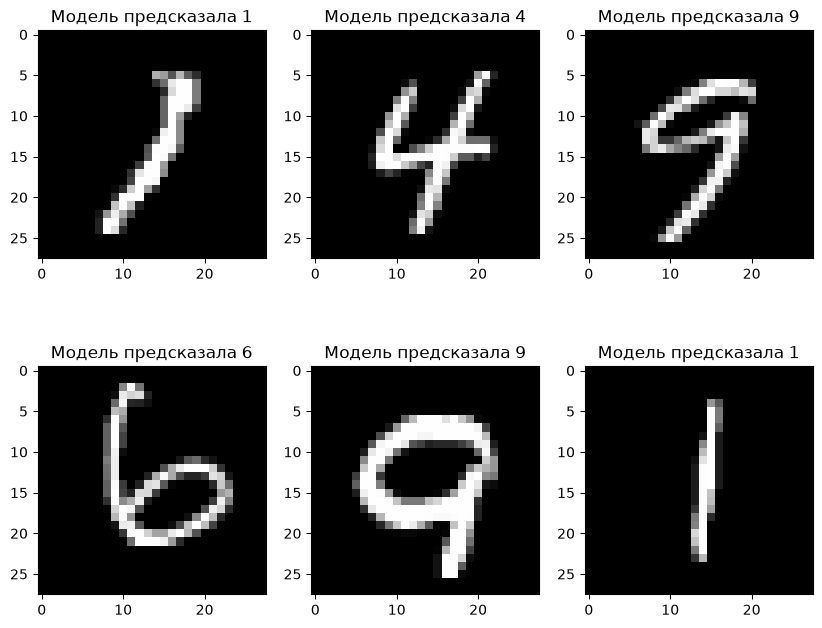

In [22]:
imgs, target = data
idx = np.random.randint(0, 60000, 6)

test_data, test_target = imgs[idx], target[idx]
test_data_ = test_data.reshape(6, -1)
test_data_ = normalize(test_data_)

pred = softmax((relu(test_data_ @ W1 + b1) @ W2 + b2))

fig, ax = plt.subplots(2, 3, figsize=(10, 8))
ax = ax.flatten()
for i in range(len(ax)):
    ax[i].imshow(test_data[i], cmap="grey")
    ax[i].set_title(f"Модель предсказала {np.argmax(pred[i])}")